# Customer Churn & Customer Value Analysis

## Project Objective

This project analyzes customer churn behavior using a telecommunications customer dataset.

The objectives are:

- Understand overall customer churn patterns
- Identify factors associated with churn
- Segment customers by value
- Provide actionable business recommendations to improve retention

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab

# 1. Data Loading

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
import os

os.makedirs(
    'images',
    exist_ok=True
)

# 2. Data Cleaning

The data cleaning process includes:

- Data type conversion
- Missing value identification
- Missing value treatment

In [29]:
df.shape

(7043, 21)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [31]:
df['TotalCharges'].head() #数据类型是object，所以要数据清洗
df['TotalCharges'].sample(10)

,TotalCharges
848,6782.15
6626,573.75
1083,171.15
3561,2088.8
3287,1875.55
3418,6118.95
903,6068.65
311,1886.25
1246,4730.9
1906,1382.9


In [32]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [33]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [34]:
df = df.dropna() #删除这11条数据

df.shape

(7032, 21)

In [35]:
print("Original records: 7043") #保存一个分析结果
print("After cleaning:", len(df))

Original records: 7043
After cleaning: 7032


# 3. Overall Customer Churn Analysis

Analyze overall customer churn distribution.

In [36]:
df['Churn'].value_counts() #Yes = 已流失客户，No = 仍然留存客户

,count
Churn,
No,5163
Yes,1869


In [37]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


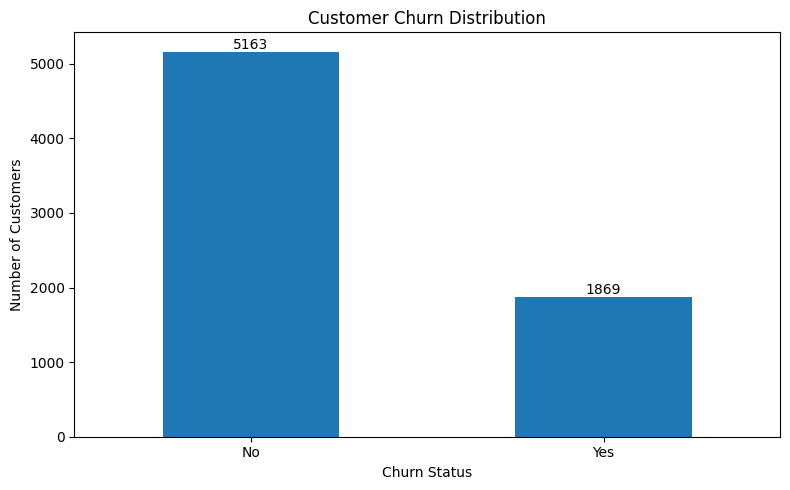

In [38]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

ax = churn_counts.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

# 添加数值标签
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.savefig(
    'images/churn_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Finding

✅️Overall churn rate is approximately 26.6%, indicating that customer retention is a significant business concern.

# 4. Contract Type Analysis

Evaluate churn rates across different contract types.

In [39]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


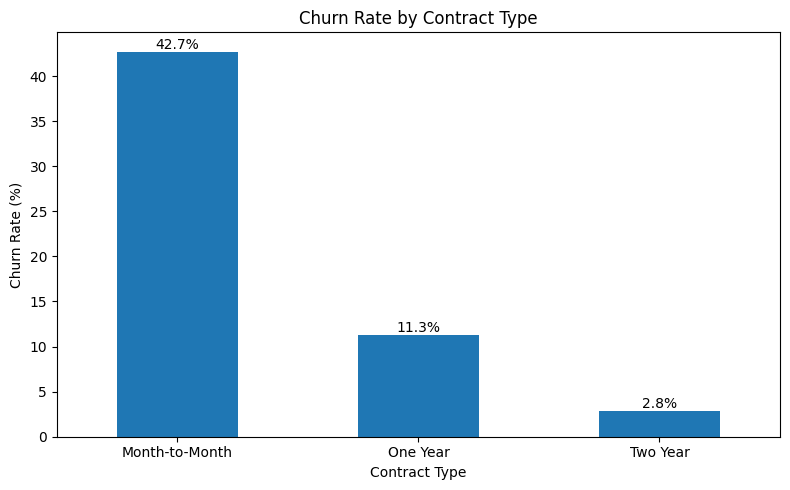

In [40]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn.index = [
    'Month-to-Month',
    'One Year',
    'Two Year'
]

ax = contract_churn['Yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)

# 添加百分比标签
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.savefig(
    'images/contract_churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Finding

✅️Month-to-month customers exhibit the highest churn rate (42.7%), while Two-Year customers demonstrate the strongest retention.

# 5. Payment Method Analysis

Analyze the relationship between payment methods and churn behavior.

In [41]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


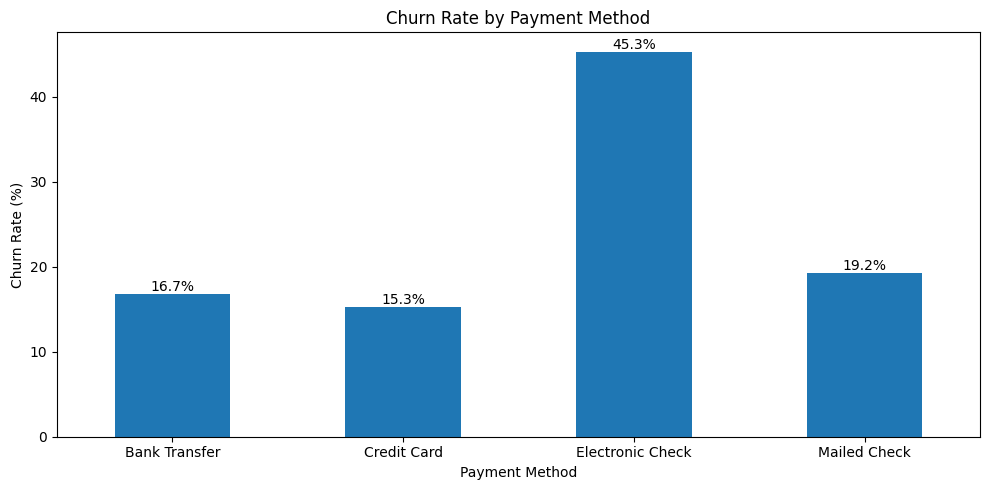

In [42]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn.index = [
    'Bank Transfer',
    'Credit Card',
    'Electronic Check',
    'Mailed Check'
]

ax = payment_churn['Yes'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)

# 添加百分比标签
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.savefig(
    'images/payment_churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Finding

✅️Electronic Check users show the highest churn rate (45.3%), suggesting potential retention opportunities through payment optimization.

# 6. Customer Value Segmentation

Customers are segmented into High-, Medium-, and Low-Value groups based on Total Charges.

In [43]:
df[['MonthlyCharges',
    'TotalCharges',
    'tenure']].describe()

,MonthlyCharges,TotalCharges,tenure
count,7032.000000,7032.000000,7032.000000
mean,64.798208,2283.300441,32.421786
std,30.085974,2266.771362,24.545260
min,18.250000,18.800000,1.000000
25%,35.587500,401.450000,9.000000
50%,70.350000,1397.475000,29.000000
75%,89.862500,3794.737500,55.000000
max,118.750000,8684.800000,72.000000


In [44]:
df['TotalCharges'].quantile([0.25,0.5,0.75])

,TotalCharges
0.25,401.4500
0.50,1397.4750
0.75,3794.7375


In [45]:
def customer_segment(x):
    if x <= 401.45:
        return 'Low Value'
    elif x <= 3794.74:
        return 'Medium Value'
    else:
        return 'High Value'

df['CustomerSegment'] = df['TotalCharges'].apply(customer_segment)

In [46]:
df['CustomerSegment'].value_counts()

,count
CustomerSegment,
Medium Value,3516
Low Value,1758
High Value,1758


In [47]:
pd.crosstab(
    df['CustomerSegment'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
CustomerSegment,,
High Value,85.494881,14.505119
Low Value,56.541524,43.458476
Medium Value,75.824801,24.175199


In [48]:
segment_churn = pd.crosstab(
    df['CustomerSegment'],
    df['Churn'],
    normalize='index'
) * 100

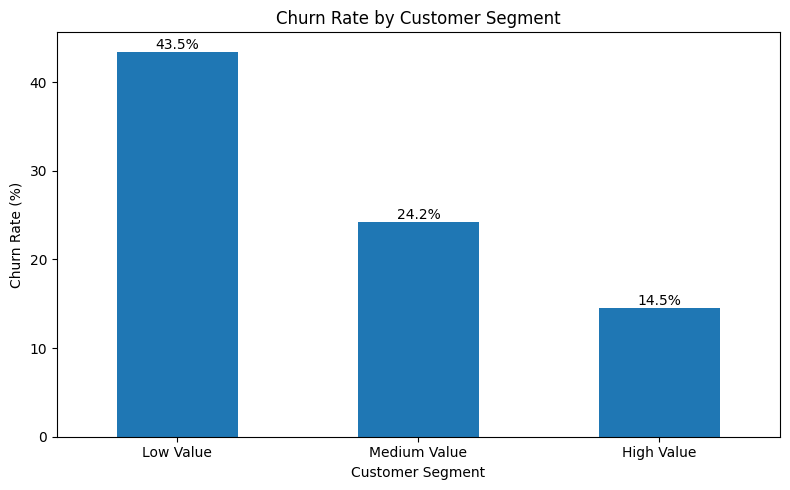

In [49]:
segment_churn = pd.crosstab(
    df['CustomerSegment'],
    df['Churn'],
    normalize='index'
) * 100

# 按价值顺序排列
segment_churn = segment_churn.reindex([
    'Low Value',
    'Medium Value',
    'High Value'
])

ax = segment_churn['Yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)

# 添加百分比标签
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.savefig(
    'images/segment_churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Finding

✅️Low-value customers exhibit the highest churn rate (43.5%), while high-value customers demonstrate stronger retention.

# 7. Customer Lifecycle Analysis

Analyze customer tenure and its relationship with churn.

In [50]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


In [51]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=[
        '0-12 Months',
        '13-24 Months',
        '25-48 Months',
        '49-72 Months'
    ]
)

tenure_churn = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 Months,52.321839,47.678161
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


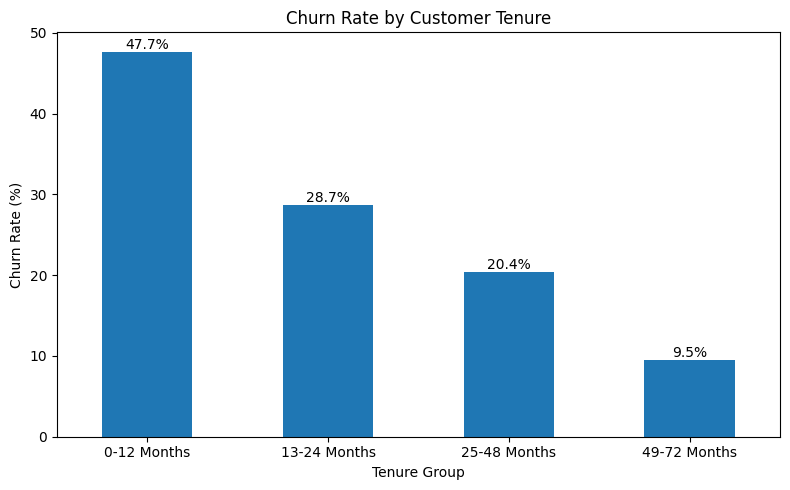

In [52]:
ax = tenure_churn['Yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)

# 添加百分比标签
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.savefig(
    'images/tenure_churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [53]:
!zip -r images.zip images

  adding: images/ (stored 0%)
  adding: images/payment_churn.png (deflated 28%)
  adding: images/tenure_churn.png (deflated 26%)
  adding: images/churn_distribution.png (deflated 30%)
  adding: images/segment_churn.png (deflated 26%)
  adding: images/contract_churn.png (deflated 26%)


### Key Finding

✅️Customers with shorter tenure are significantly more likely to churn compared to long-tenure customers.

# 8. Key Business Findings

1. Overall churn rate reached 26.6%.

2. Month-to-month customers have the highest churn rate (42.7%).

3. Electronic Check users exhibit the highest churn risk (45.3%).

4. Low-value customers are more likely to churn (43.5%).

5. Customer churn is concentrated among early-stage customers.

# 9. Business Recommendations
1.Encourage Month-to-Month customers to upgrade to longer-term contracts.

2.Promote automatic payment methods to improve retention.

3.Develop retention campaigns targeting low-value customers.

4.Strengthen onboarding and engagement strategies for newly acquired customers.

# Conclusion

This project analyzed customer churn behavior using a telecommunications customer dataset.

Through customer segmentation, contract analysis, payment behavior analysis, and customer lifecycle analysis, several key drivers of churn were identified.

The findings suggest that customer retention can be improved through long-term contract adoption, automated payment methods, targeted retention campaigns, and enhanced onboarding strategies for new customers.

# Project Summary

## Key Findings

1. Overall churn rate reached 26.6%.

2. Month-to-month customers exhibited the highest churn rate (42.7%).

3. Electronic Check users showed the highest churn risk (45.3%).

4. Low-value customers experienced significantly higher churn (43.5%).

5. Customer churn was concentrated among early-stage customers.